1.  Como o desempenho varia por faixa etária?
2. Qual é a distribuição de idade dos participantes? (histograma)
3. Proporção de cor/raça? (grafico de pizza)
4. O grau de ocupação do pai e a media de nota
5. O grau de ocupação da mae e a media da nota
7. O grau de ensino dos pais tem impacto, qual tem o maior impacto, da mãe ou do pai
8. Qual a média de renda per capta baseado na Cor ou raça, a nota média é impactada por esses fatores

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('df_enem_2023_ceara.csv')
df

,Número de Inscrição,Ano do Enem,Faixa Etária,Sexo,Estado Civil,Cor/Raça,Nacionalidade,Situação de Conclusão do Ensino Médio,Ano de Conclusão do Ensino Médio,Tipo de Escola do Ensino Médio,...,Forno Micro-ondas na Residência,Máquina de Lavar Louça na Residência,Aspirador de Pó na Residência,Televisão em Cores na Residência,Aparelho de DVD na Residência,TV por Assinatura na Residência,Telefone Celular na Residência,Telefone Fixo na Residência,Computador na Residência,Acesso à Internet na Residência
0,210060214087,2023,17 anos,F,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, três",Não,Não,Sim
1,210059980948,2023,18 anos,F,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Não
2,210059388092,2023,18 anos,F,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Sim
3,210060373830,2023,17 anos,F,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Sim
4,210060440974,2023,19 anos,F,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Sim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74314,210061008506,2023,19 anos,M,1,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, duas",Não,Não,"Sim, três",Não,"Sim, um",Sim
74315,210060298399,2023,17 anos,M,1,Branca,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Privada,...,"Sim, um",Não,Sim,"Sim, duas",Sim,Sim,"Sim, quatro ou mais",Não,"Sim, quatro ou mais",Sim
74316,210061481447,2023,Entre 26 e 30 anos,M,2,Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não
74317,210059173679,2023,24 anos,F,1,Branca,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, duas",Não,Não,"Sim, quatro ou mais",Sim,"Sim, um",Sim


In [3]:

colunas_notas = [
    'Nota Ciências da Natureza', 
    'Nota Ciências Humanas',
    'Nota Linguagens e Códigos', 
    'Nota Matemática',
    'Nota Redação'
]


In [4]:
df['nota_media'] =(df['Nota Ciências da Natureza'] + df['Nota Ciências Humanas'] + df['Nota Linguagens e Códigos'] + df['Nota Matemática'] + df['Nota Redação'])/5
df['nota_media']

0        564.28
1        425.38
2        658.92
3        566.64
4        397.24
          ...  
74314    635.50
74315    618.22
74316    360.44
74317    578.44
74318    316.52
Name: nota_media, Length: 74319, dtype: float64

In [5]:
df['Media_Geral'] = df[colunas_notas].mean(axis=1)

1.  Como o desempenho varia por faixa etária?

In [6]:
df_agrupado = df.groupby('Faixa Etária')['Media_Geral'].mean().reset_index()

C:\Users\pvito\AppData\Local\Temp\ipykernel_16312\195372410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_agrupado, x='Faixa Etária', y='Media_Geral', palette='viridis')


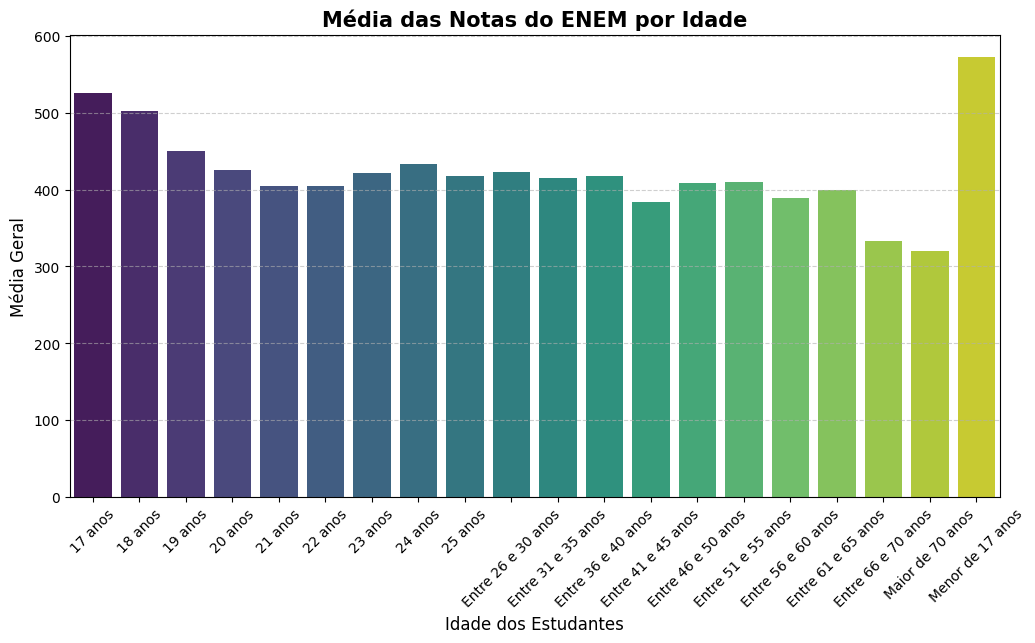

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_agrupado, x='Faixa Etária', y='Media_Geral', palette='viridis')

# Customização visual
plt.title('Média das Notas do ENEM por Idade', fontsize=15, fontweight='bold')
plt.xlabel('Idade dos Estudantes', fontsize=12)
plt.ylabel('Média Geral', fontsize=12)
plt.xticks(rotation=45) # Inclina as idades se houver muitas, para não embolar
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

2. Qual é a distribuição de idade dos participantes? (histograma)

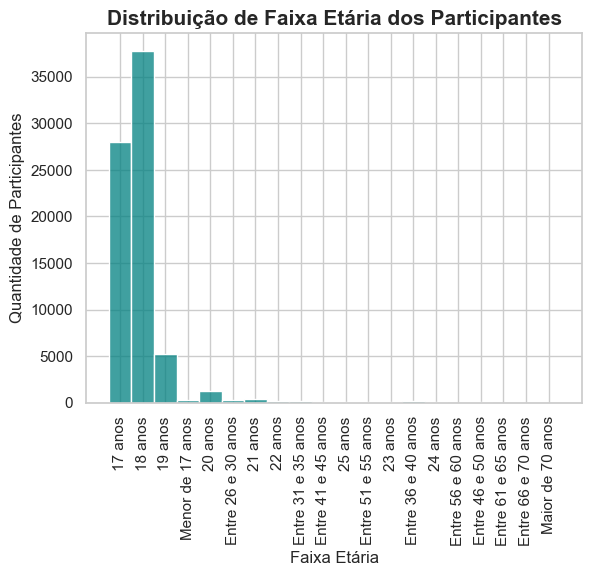

In [8]:
sns.set_theme(style="whitegrid")

plt.xticks(rotation=90)

# Criando o histograma
# kde=True adiciona uma linha de densidade (suavização) sobre as barras
sns.histplot(df['Faixa Etária'], bins=30, color='teal')

# Customização
plt.title('Distribuição de Faixa Etária dos Participantes', fontsize=15, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Quantidade de Participantes', fontsize=12)

plt.show()

3. Proporção de cor/raça? (grafico de pizza)

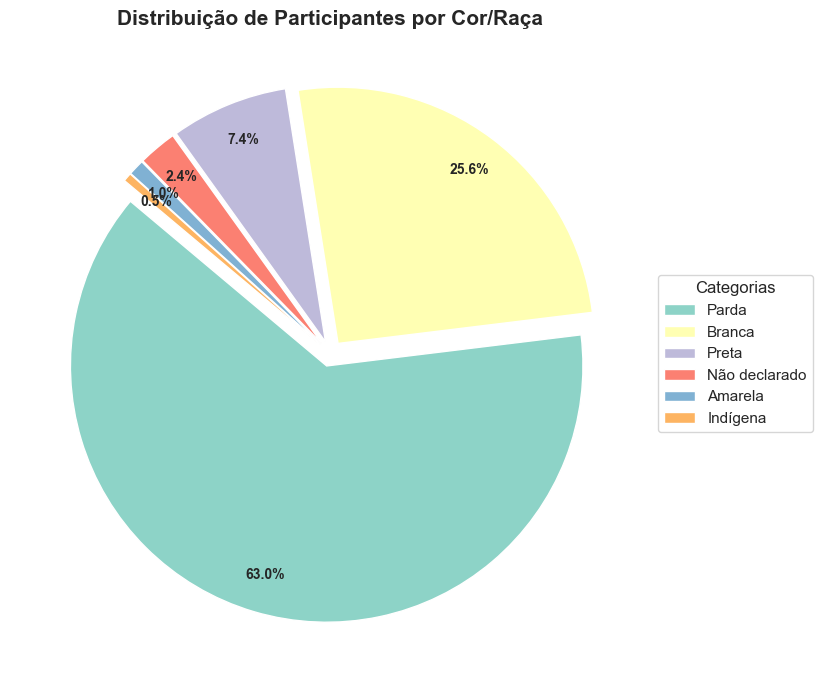

In [9]:
contagem_raca = df['Cor/Raça'].value_counts()


plt.figure(figsize=(10, 7))
sns.set_palette("Set3") # Paleta de cores suave


# Removi os labels de cima das fatias para usar a legenda depois
wedges, texts, autotexts = plt.pie(
    contagem_raca, 
    autopct='%1.1f%%', 
    startangle=140, 
    pctdistance=0.85, # Afasta a porcentagem do centro
    explode=[0.05] * len(contagem_raca)
)

# Deixar as porcentagens em negrito para facilitar a leitura
plt.setp(autotexts, size=10, weight="bold")


plt.legend(
    wedges, 
    contagem_raca.index,
    title="Categorias",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Posiciona fora do círculo
)

plt.title('Distribuição de Participantes por Cor/Raça', fontsize=15, fontweight='bold')
plt.tight_layout() # Ajusta o gráfico para não cortar a legenda

plt.show()

4. O grau de ocupação do pai e a media de nota

C:\Users\pvito\AppData\Local\Temp\ipykernel_16312\2397010184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


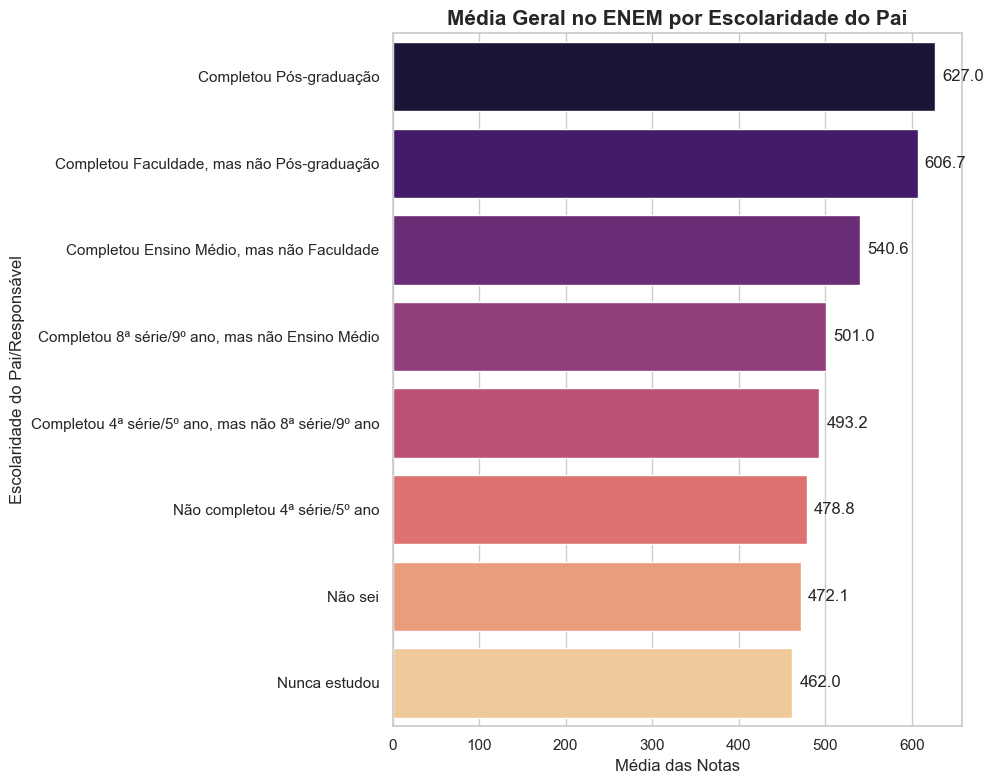

In [10]:
df_pai = df.groupby('Escolaridade do Pai/Responsável Homem')['Media_Geral'].mean().sort_values(ascending=False).reset_index()

# 2. Configurar o estilo visual
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 3. Criar o gráfico de barras horizontais (trocamos x por y para os nomes ficarem deitados)
grafico = sns.barplot(
    data=df_pai, 
    x='Media_Geral', 
    y='Escolaridade do Pai/Responsável Homem', 
    palette='magma'
)

# 4. Adicionar os valores exatos nas pontas das barras para facilitar a leitura
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.1f', padding=5)

# Customização de títulos
plt.title('Média Geral no ENEM por Escolaridade do Pai', fontsize=15, fontweight='bold')
plt.xlabel('Média das Notas', fontsize=12)
plt.ylabel('Escolaridade do Pai/Responsável', fontsize=12)

# Ajustar o layout para o texto não sair da imagem
plt.tight_layout()

plt.show()

5. O grau de ocupação da mae e a media da nota

C:\Users\pvito\AppData\Local\Temp\ipykernel_16312\2646017697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_mae = sns.barplot(


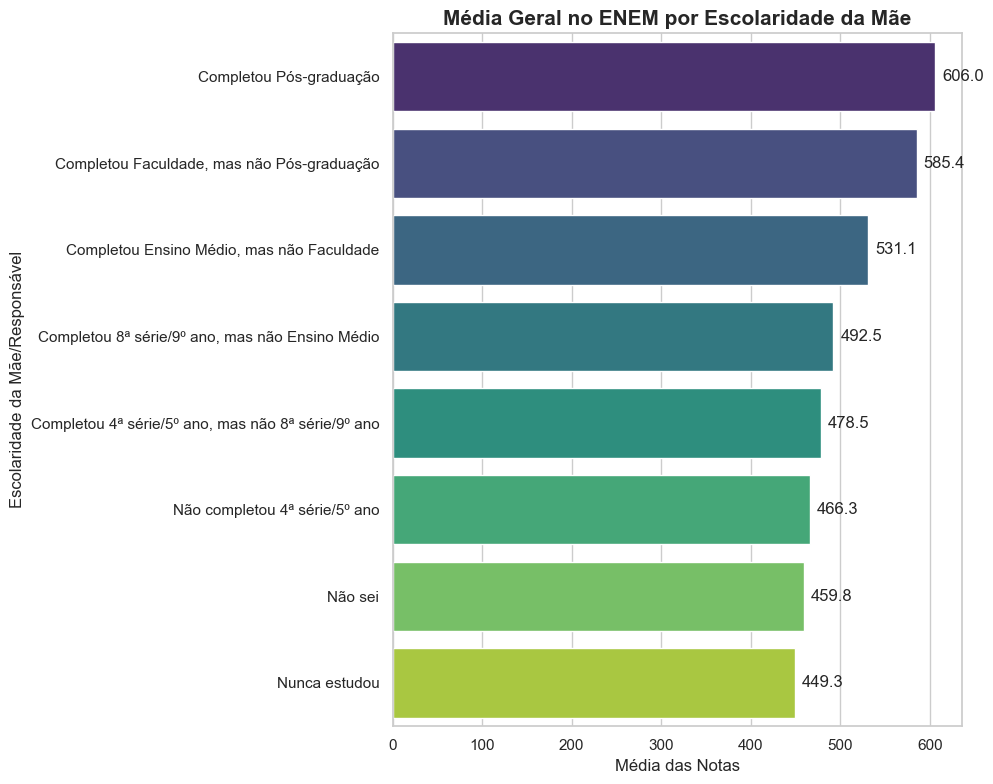

In [11]:

df_mae = df.groupby('Escolaridade da Mãe/Responsável Mulher')['Media_Geral'].mean().sort_values(ascending=False).reset_index()


plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")


grafico_mae = sns.barplot(
    data=df_mae, 
    x='Media_Geral', 
    y='Escolaridade da Mãe/Responsável Mulher', 
    palette='viridis' # Uma paleta de cores diferente para diferenciar do gráfico do pai
)


for i in grafico_mae.containers:
    grafico_mae.bar_label(i, fmt='%.1f', padding=5)


plt.title('Média Geral no ENEM por Escolaridade da Mãe', fontsize=15, fontweight='bold')
plt.xlabel('Média das Notas', fontsize=12)
plt.ylabel('Escolaridade da Mãe/Responsável', fontsize=12)


plt.tight_layout()

plt.show()

7. O grau de ensino dos pais tem impacto, qual tem o maior impacto, da mãe ou do pai

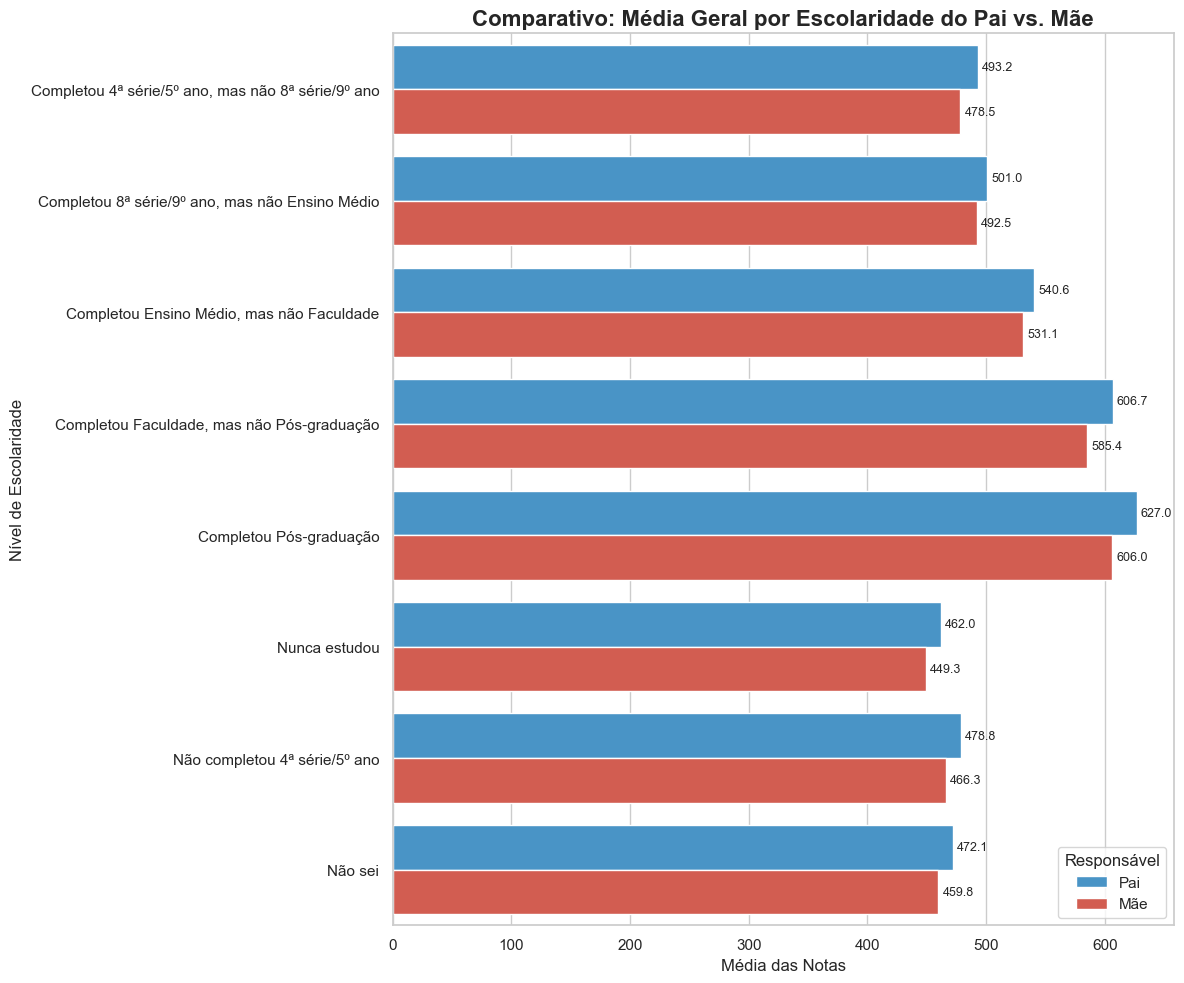

In [12]:
media_pai = df.groupby('Escolaridade do Pai/Responsável Homem')['Media_Geral'].mean().rename('Pai')
media_mae = df.groupby('Escolaridade da Mãe/Responsável Mulher')['Media_Geral'].mean().rename('Mãe')


df_comparativo = pd.concat([media_pai, media_mae], axis=1).reset_index()
df_comparativo.columns = ['Escolaridade', 'Pai', 'Mãe']


df_plot = df_comparativo.melt(id_vars='Escolaridade', var_name='Responsável', value_name='Média Geral')


plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    data=df_plot, 
    y='Escolaridade', 
    x='Média Geral', 
    hue='Responsável', 
    palette=['#3498db', '#e74c3c'] # Azul para Pai, Vermelho para Mãe
)


for i in grafico.containers:
    grafico.bar_label(i, fmt='%.1f', padding=3, fontsize=9)

plt.title('Comparativo: Média Geral por Escolaridade do Pai vs. Mãe', fontsize=16, fontweight='bold')
plt.xlabel('Média das Notas', fontsize=12)
plt.ylabel('Nível de Escolaridade', fontsize=12)
plt.legend(title='Responsável', loc='lower right')

plt.tight_layout()
plt.show()

8. Qual a média de renda per capta baseado na Cor ou raça, a nota média é impactada por esses fatores

Faixa_Renda
Baixa (Até R$ 1.980)           59787
Média (R$ 1.980 a R$ 6.600)    11132
Alta (Acima de R$ 6.600)        3400
Name: count, dtype: int64


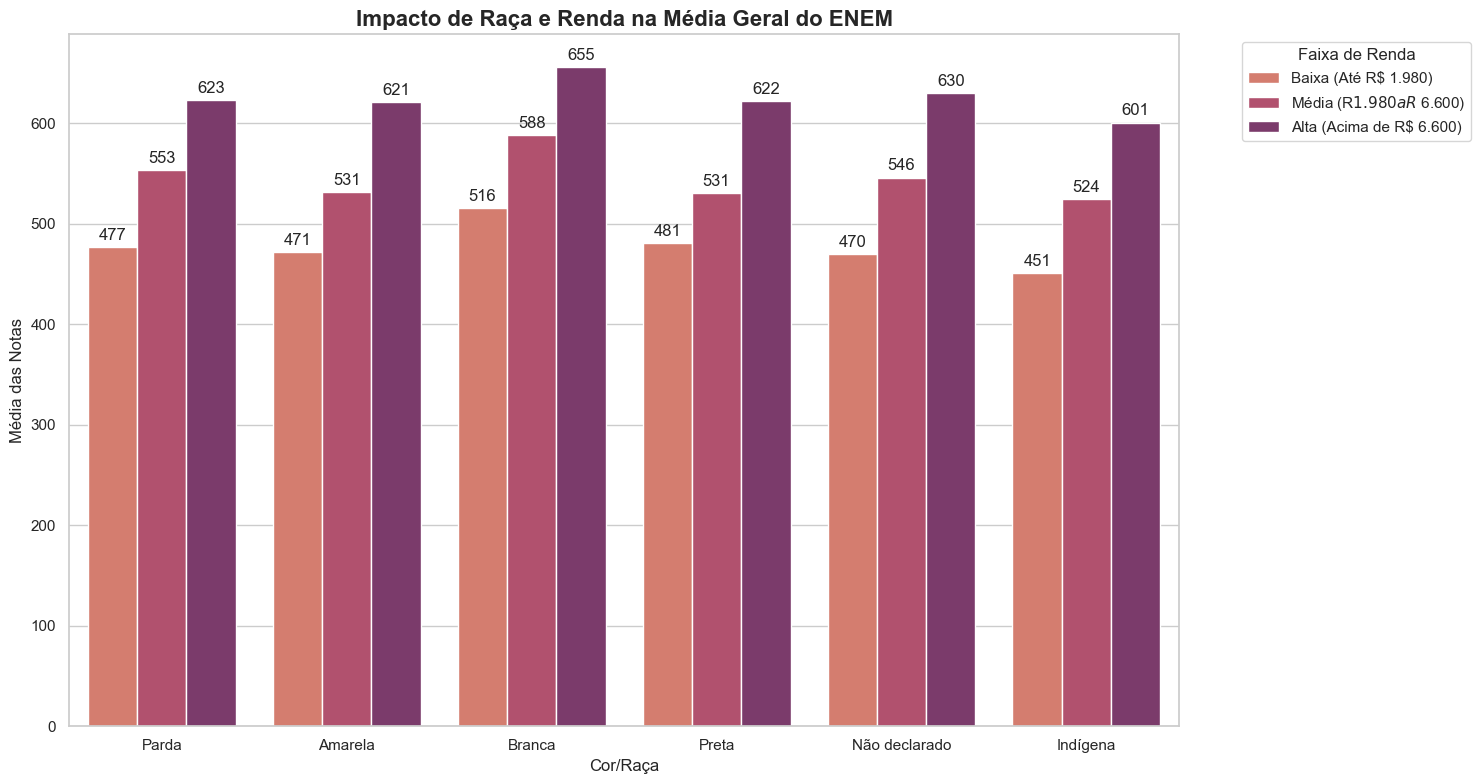

In [13]:

baixa_renda = [
    'Nenhuma Renda', 
    'Até R$ 1.320,00', 
    'De R$ 1.320,01 até R$ 1.980,00'
]

media_renda = [
    'De R$ 1.980,01 até R$ 2.640,00', 
    'De R$ 2.640,01 até R$ 3.300,00',
    'De R$ 3.300,01 até R$ 3.960,00',
    'De R$ 3.960,01 até R$ 5.280,00',
    'De R$ 5.280,01 até R$ 6.600,00'
]


condicoes = [
    df['Renda Mensal Familiar'].isin(baixa_renda),
    df['Renda Mensal Familiar'].isin(media_renda)
]

valores = ['Baixa (Até R$ 1.980)', 'Média (R$ 1.980 a R$ 6.600)']

# O que não for Baixa ou Média, será considerado Alta
df['Faixa_Renda'] = np.select(condicoes, valores, default='Alta (Acima de R$ 6.600)')

# --- VERIFICAÇÃO ---
print(df['Faixa_Renda'].value_counts())

# --- GRÁFICO ---
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    data=df, 
    x='Cor/Raça', 
    y='Media_Geral', 
    hue='Faixa_Renda',
    hue_order=['Baixa (Até R$ 1.980)', 'Média (R$ 1.980 a R$ 6.600)', 'Alta (Acima de R$ 6.600)'],
    palette='flare', # Aquela paleta moderna que você escolheu
    errorbar=None
)

# Adiciona os números em cima das barras
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.0f', padding=3)

plt.title('Impacto de Raça e Renda na Média Geral do ENEM', fontsize=16, fontweight='bold')
plt.ylabel('Média das Notas')
plt.legend(title='Faixa de Renda', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()